In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

file_path = "D:/Documents/Projects/Intern/Datasets_Provided/Churn Prdiction Data/churn-bigml-80.csv"
df = pd.read_csv(file_path)

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


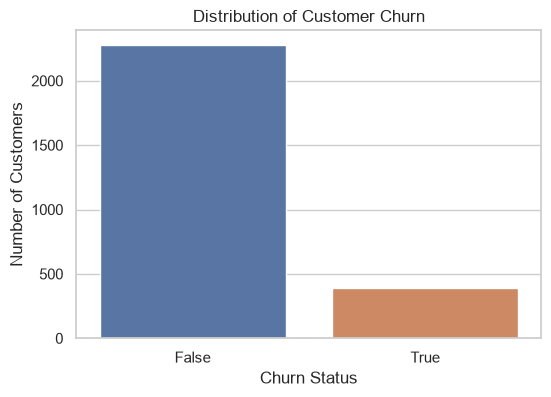

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette=["#4C72B0", "#DD8452"],
    legend=False
)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

In [13]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
churn_percentage

Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64

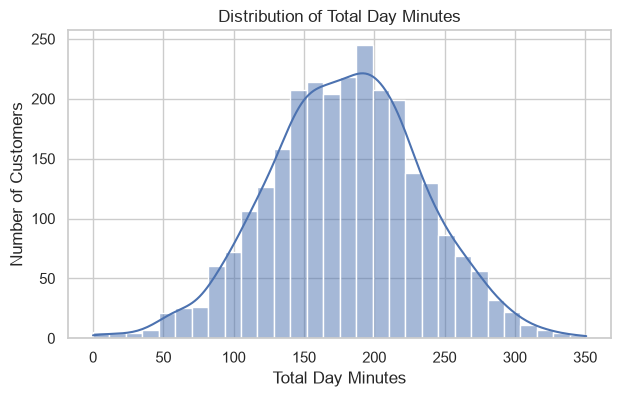

In [14]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=df,
    x="Total day minutes",
    bins=30,
    kde=True,
    color="#4C72B0"
)

plt.title("Distribution of Total Day Minutes")
plt.xlabel("Total Day Minutes")
plt.ylabel("Number of Customers")
plt.show()

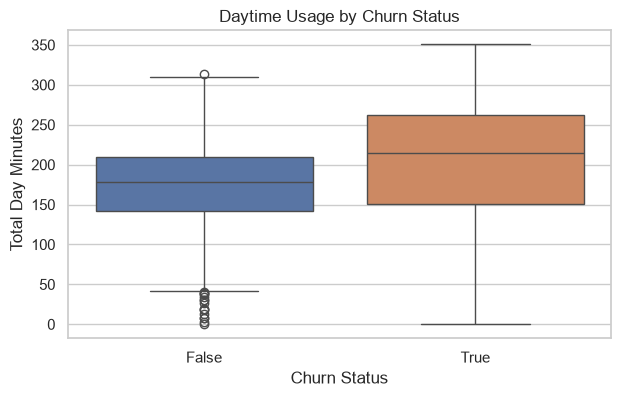

In [15]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Churn",
    y="Total day minutes",
    hue="Churn",
    palette=["#4C72B0", "#DD8452"],
    legend=False
)

plt.title("Daytime Usage by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Total Day Minutes")
plt.show()

In [16]:
df.groupby("Churn")["Total day minutes"].mean()

Churn
False    175.104346
True     205.181186
Name: Total day minutes, dtype: float64

In [17]:
international_churn = (
    df.groupby("International plan")["Churn"]
      .mean()
      .reset_index()
)

international_churn["Churn rate"] = (
    international_churn["Churn"] * 100
)

international_churn

,International plan,Churn,Churn rate
0,No,0.112688,11.268781
1,Yes,0.437037,43.703704


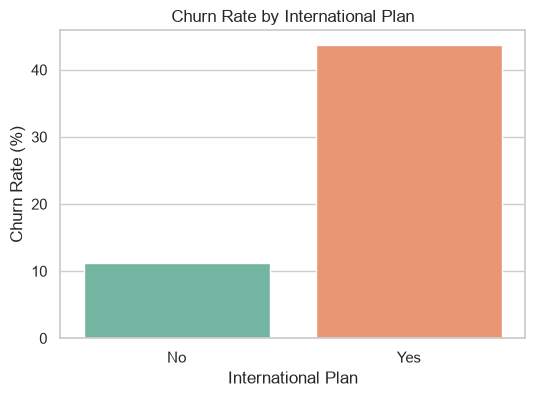

In [18]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=international_churn,
    x="International plan",
    y="Churn rate",
    hue="International plan",
    palette="Set2",
    legend=False
)

plt.title("Churn Rate by International Plan")
plt.xlabel("International Plan")
plt.ylabel("Churn Rate (%)")
plt.show()